# CSE-4155: Introduction to Machine Learning
## Lab 03 — Decision Boundary Investigation and Perceptron

This notebook is organized section by section according to the lab manual.
Each section creates the relevant plot and explains the result.

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from pathlib import Path

%matplotlib inline

RANDOM_SEED = 42
LEARNING_RATE = 0.01
EPOCHS = 50
FEATURE_COLUMNS = ("x1", "x2")
TARGET_COLUMN = "y"

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

DATA_PATH = Path("perceptron_data.csv")
PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)


In [41]:

def load_data(filepath):
    df = pd.read_csv(filepath)
    required = set(FEATURE_COLUMNS) | {TARGET_COLUMN}
    if not required.issubset(df.columns):
        missing = sorted(required - set(df.columns))
        raise ValueError(f"Missing columns: {missing}")

    df = df[list(FEATURE_COLUMNS) + [TARGET_COLUMN]].dropna().reset_index(drop=True)
    X = df[list(FEATURE_COLUMNS)].to_numpy(dtype=float)
    y = df[TARGET_COLUMN].to_numpy(dtype=int)

    unique = set(np.unique(y))
    if not unique.issubset({-1, 1}):
        raise ValueError(f"Labels must be -1 or +1. Found: {sorted(unique)}")
    if len(unique) != 2:
        raise ValueError("Need both classes in the dataset.")
    return X, y

X, y = load_data(DATA_PATH)
print(f"Loaded {len(X)} samples with features {FEATURE_COLUMNS}")
print(f"Class distribution: {dict(zip(*np.unique(y, return_counts=True)))}")


Loaded 100 samples with features ('x1', 'x2')
Class distribution: {np.int64(-1): np.int64(50), np.int64(1): np.int64(50)}


In [42]:
# ---------- Animation utilities (shared by Sections 1, 2 and 4) ----------
from IPython.display import HTML, display

plt.rcParams["animation.embed_limit"] = 60     # MB, allows long inline animations
plt.rcParams["animation.frame_format"] = "jpeg"  # keeps the embedded animation (and the notebook) small


def accuracy_of(weights, X, y):
    """Fraction of points classified correctly by sign(w0 + w1*x1 + w2*x2)."""
    scores = weights[0] + X @ weights[1:]
    return float(np.mean(np.where(scores >= 0, 1, -1) == y))


def misclassified_mask(weights, X, y):
    scores = weights[0] + X @ weights[1:]
    return y * scores <= 0


def interpolate_weights(waypoints, steps_per_segment=25):
    """Smoothly move from one weight vector to the next, so the line visibly slides and rotates."""
    path = [np.asarray(waypoints[0], dtype=float)]
    for start, end in zip(waypoints[:-1], waypoints[1:]):
        start, end = np.asarray(start, dtype=float), np.asarray(end, dtype=float)
        for t in np.linspace(0, 1, steps_per_segment + 1)[1:]:
            path.append((1 - t) * start + t * end)
    return path


def truncate_at_best_accuracy(weight_path, X, y):
    """Cut the path at the FIRST step that reaches the best accuracy found along the path."""
    accuracies = [accuracy_of(w, X, y) for w in weight_path]
    stop = int(np.argmax(accuracies))          # argmax returns the first maximum
    return weight_path[: stop + 1], accuracies[: stop + 1]


def animate_boundary(X, y, weight_path, title, xlim, ylim,
                     interval=80, hold_frames=20, max_frames=60, save_path=None):
    """
    Animate the decision boundary w0 + w1*x1 + w2*x2 = 0 following `weight_path`.
    The animation stops (and freezes in green) at the first step with the best accuracy.
    """
    weight_path, accuracies = truncate_at_best_accuracy(weight_path, X, y)

    # Keep long training runs light: subsample but always keep the final step.
    if len(weight_path) > max_frames:
        idx = np.unique(np.r_[np.linspace(0, len(weight_path) - 1, max_frames).astype(int), len(weight_path) - 1])
        weight_path = [weight_path[i] for i in idx]
        accuracies = [accuracies[i] for i in idx]

    fig, ax = plt.subplots(figsize=(7, 5), dpi=70)
    plot_data(ax, X, y, title)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.legend(loc="best", fontsize=8)

    x_grid = np.linspace(xlim[0], xlim[1], 300)
    boundary, = ax.plot([], [], color="red", linewidth=2.5, zorder=3)
    ghost, = ax.plot([], [], color="red", linewidth=1.2, alpha=0.25, zorder=2)
    wrong = ax.scatter([], [], s=140, facecolors="none", edgecolors="red", linewidths=1.5, zorder=4)
    info = ax.text(0.02, 0.98, "", transform=ax.transAxes, va="top", family="monospace", fontsize=9,
                   bbox=dict(facecolor="white", alpha=0.85, edgecolor="0.7", boxstyle="round,pad=0.4"))

    def line_points(w):
        if not np.isclose(w[2], 0.0):
            return x_grid, -(w[0] + w[1] * x_grid) / w[2]
        if not np.isclose(w[1], 0.0):
            xv = -w[0] / w[1]
            return [xv, xv], list(ylim)
        return [], []

    last = len(weight_path) - 1

    def update(frame):
        k = min(frame, last)
        w = weight_path[k]
        boundary.set_data(*line_points(w))
        ghost.set_data(*line_points(weight_path[k - 1])) if k > 0 else ghost.set_data([], [])
        bad = misclassified_mask(w, X, y)
        wrong.set_offsets(X[bad] if bad.any() else np.empty((0, 2)))
        slope = "vertical" if np.isclose(w[2], 0.0) else f"{-w[1] / w[2]:+.3f}"
        done = frame >= last
        boundary.set_color("green" if done else "red")
        info.set_text(
            f"step {k}/{last}\n"
            f"w = [{w[0]:+.3f}, {w[1]:+.3f}, {w[2]:+.3f}]\n"
            f"slope = {slope}\n"
            f"accuracy = {100 * accuracies[k]:.1f}%" + ("\nBEST ACCURACY REACHED" if done else "")
        )
        return boundary, ghost, wrong, info

    anim = FuncAnimation(fig, update, frames=len(weight_path) + hold_frames, interval=interval,
                         blit=False, repeat=False)
    if save_path is not None:
        anim.save(save_path, writer="pillow", fps=max(1, int(1000 / interval)))
    plt.close(fig)                       # avoid a duplicate static figure under the animation
    display(HTML(anim.to_jshtml()))      # inline playable animation (works with %matplotlib inline)
    return anim


## Section 1: Decision Boundary Investigation

Use different values of $w_0$, $w_1$, and $w_2$ to see how the boundary shifts and rotates.

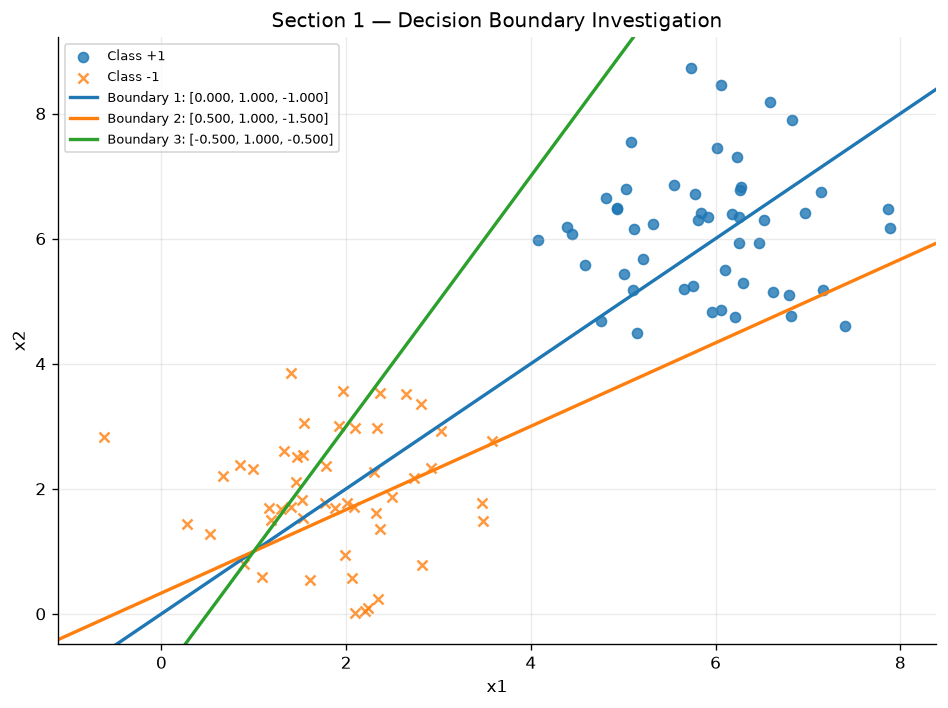

In [43]:
def decision_boundary_x(weights, x_values):
    w0, w1, w2 = weights
    if np.isclose(w2, 0.0):
        return None
    return -(w0 + w1 * x_values) / w2


def plot_data(ax, X, y, title):
    pos = y == 1
    neg = y == -1
    ax.scatter(X[pos, 0], X[pos, 1], marker='o', label='Class +1', alpha=0.8)
    ax.scatter(X[neg, 0], X[neg, 1], marker='x', label='Class -1', alpha=0.8)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    ax.legend()


def plot_boundary(ax, weights, x_limits, label):
    x_values = np.linspace(x_limits[0], x_limits[1], 300)
    y_values = decision_boundary_x(weights, x_values)
    w0, w1, w2 = weights
    if y_values is not None:
        ax.plot(x_values, y_values, linewidth=2, label=f"{label}: [{w0:.3f}, {w1:.3f}, {w2:.3f}]")
    elif not np.isclose(w1, 0.0):
        x_vertical = -w0 / w1
        ax.axvline(x_vertical, linewidth=2, label=f"{label}: x1={x_vertical:.3f}")

manual_boundaries = [
    np.array([0.0, 1.0, -1.0]),
    np.array([0.5, 1.0, -1.5]),
    np.array([-0.5, 1.0, -0.5]),
]

x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
fig, ax = plt.subplots(figsize=(8, 6))
plot_data(ax, X, y, 'Section 1 — Decision Boundary Investigation')
for index, weights in enumerate(manual_boundaries, start=1):
    plot_boundary(ax, weights, (x_min, x_max), f'Boundary {index}')
ax.set_xlim(x_min, x_max)
ax.set_ylim(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(PLOTS_DIR / '01_decision_boundary_investigation.png', dpi=150)
plt.show()

# Animated version: the line slides/rotates through the weight vectors above (plus a few extra
# waypoints) and freezes at the first step that reaches the best accuracy.
animation_waypoints = manual_boundaries + [
    np.array([-4.0, 1.0, 0.5]),
    np.array([-9.0, 1.0, 1.0]),
]
section1_path = interpolate_weights(animation_waypoints, steps_per_segment=20)
y_limits = (X[:, 1].min() - 0.5, X[:, 1].max() + 0.5)
animate_boundary(X, y, section1_path, 'Section 1 — Animated Boundary Change',
                 xlim=(x_min, x_max), ylim=y_limits,
                 interval=80, save_path=PLOTS_DIR / '01_decision_boundary_animation.gif')


## Section 2: Perceptron Training and Initial vs Final Decision Boundary

Train a perceptron from scratch and compare the initial and final boundaries.

Initial weights: [ 0.5479121  -0.12224312  0.71719584]
Final weights: [-0.1820879   0.04410247  0.00519275]
Final training errors: 0


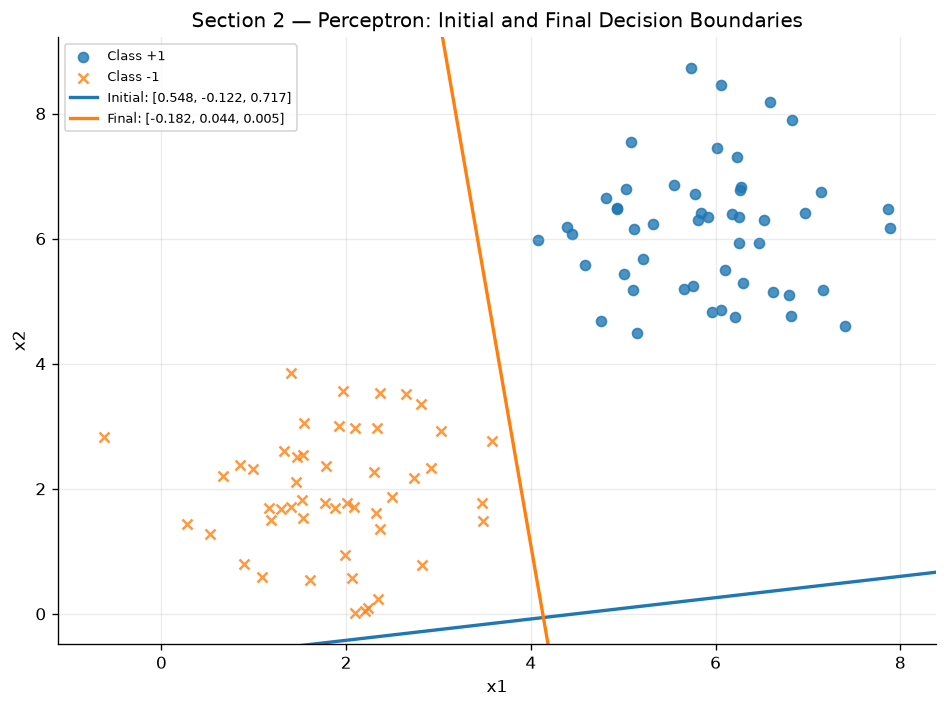

In [44]:

def initialize_parameters(seed=RANDOM_SEED, low=-1.0, high=1.0):
    rng = np.random.default_rng(seed)
    return rng.uniform(low, high, size=3)


def add_bias(X):
    return np.c_[np.ones(X.shape[0]), X]


def predict(X, weights):
    scores = add_bias(X) @ weights
    return np.where(scores >= 0, 1, -1)


def compute_loss(X, y, weights):
    margins = y * (add_bias(X) @ weights)
    return int(np.sum(margins <= 0))


def update_weights(weights, x_i, y_i, learning_rate):
    return weights + learning_rate * y_i * x_i


def train_perceptron(X, y, learning_rate=LEARNING_RATE, epochs=EPOCHS, initial_weights=None, weight_history=None):
    X_with_bias = add_bias(X)
    weights = initialize_parameters() if initial_weights is None else np.asarray(initial_weights, dtype=float).copy()
    if weights.shape != (3,):
        raise ValueError('weights must have shape (3,)')

    epoch_errors = []
    if weight_history is not None:
        weight_history.append(weights.copy())  # initial weights
    for _ in range(epochs):
        for x_i, y_i in zip(X_with_bias, y):
            if y_i * np.dot(weights, x_i) <= 0:
                weights = update_weights(weights, x_i, y_i, learning_rate)
                if weight_history is not None:
                    weight_history.append(weights.copy())  # one entry per weight update
        epoch_errors.append(compute_loss(X, y, weights))
    return weights, epoch_errors

initial_weights = initialize_parameters(seed=RANDOM_SEED)
weight_history = []
final_weights, epoch_errors = train_perceptron(X, y, learning_rate=LEARNING_RATE, epochs=EPOCHS, initial_weights=initial_weights, weight_history=weight_history)
print(f"Initial weights: {initial_weights}")
print(f"Final weights: {final_weights}")
print(f"Final training errors: {epoch_errors[-1]}")

fig, ax = plt.subplots(figsize=(8, 6))
plot_data(ax, X, y, 'Section 2 — Perceptron: Initial and Final Decision Boundaries')
plot_boundary(ax, initial_weights, (X[:, 0].min() - 0.5, X[:, 0].max() + 0.5), 'Initial')
plot_boundary(ax, final_weights, (X[:, 0].min() - 0.5, X[:, 0].max() + 0.5), 'Final')
ax.set_xlim(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5)
ax.set_ylim(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(PLOTS_DIR / '02_initial_vs_final_boundary.png', dpi=150)
plt.show()

# Animated version: the boundary moves after every weight update and stops at the best accuracy.
animate_boundary(X, y, weight_history, 'Section 2 — Animated Perceptron Learning',
                 xlim=(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5),
                 ylim=(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5),
                 interval=120, save_path=PLOTS_DIR / '02_perceptron_learning_animation.gif')


## Section 3: Classification Error vs Epoch

The perceptron learning curve shows how the number of misclassifications decreases over epochs.

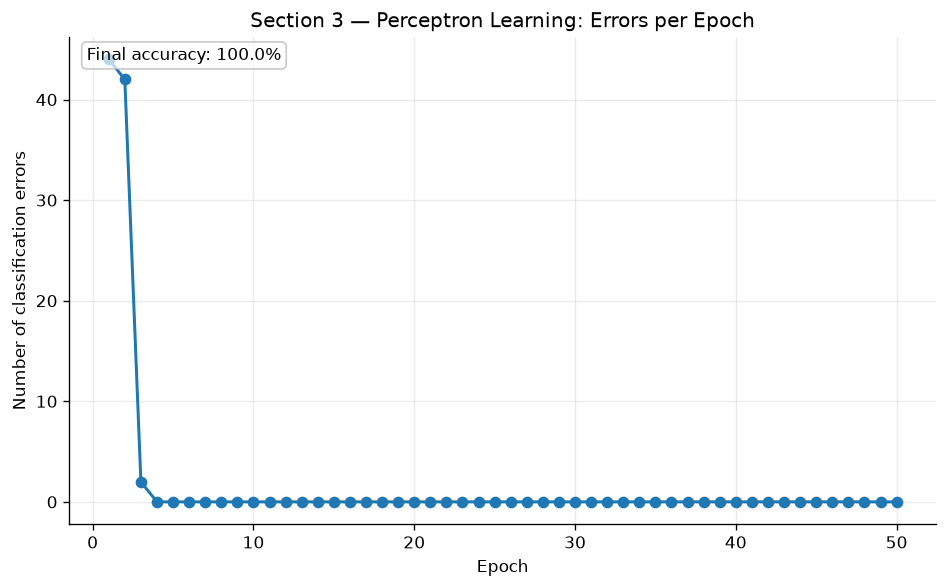

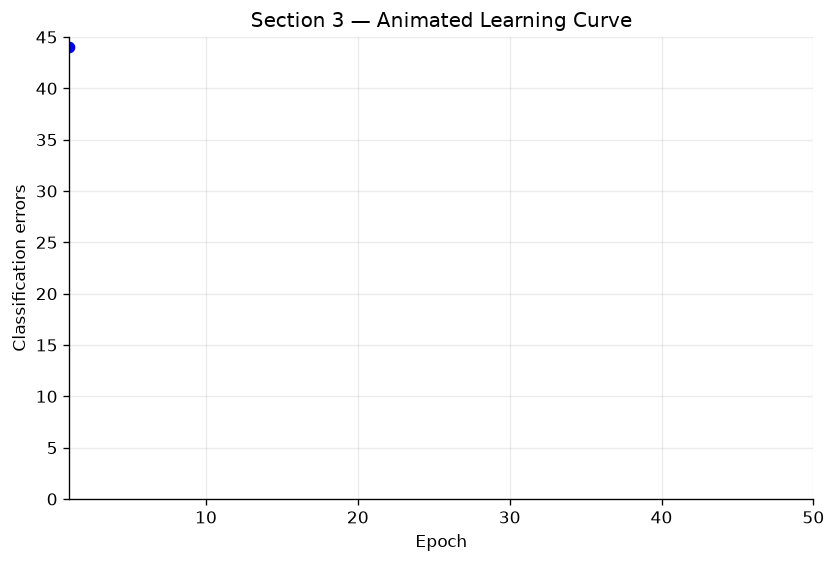


Perceptron learning summary
Epoch | Errors | Accuracy
----- | ------ | --------
    1 |     44 |   56.00%
    2 |     42 |   58.00%
    3 |      2 |   98.00%
    4 |      0 |  100.00%
    5 |      0 |  100.00%
    6 |      0 |  100.00%
    7 |      0 |  100.00%
    8 |      0 |  100.00%
    9 |      0 |  100.00%
   10 |      0 |  100.00%
   11 |      0 |  100.00%
   12 |      0 |  100.00%
   13 |      0 |  100.00%
   14 |      0 |  100.00%
   15 |      0 |  100.00%
   16 |      0 |  100.00%
   17 |      0 |  100.00%
   18 |      0 |  100.00%
   19 |      0 |  100.00%
   20 |      0 |  100.00%
   21 |      0 |  100.00%
   22 |      0 |  100.00%
   23 |      0 |  100.00%
   24 |      0 |  100.00%
   25 |      0 |  100.00%
   26 |      0 |  100.00%
   27 |      0 |  100.00%
   28 |      0 |  100.00%
   29 |      0 |  100.00%
   30 |      0 |  100.00%
   31 |      0 |  100.00%
   32 |      0 |  100.00%
   33 |      0 |  100.00%
   34 |      0 |  100.00%
   35 |      0 |  100.00%
   36 |  

In [45]:
epochs = np.arange(1, len(epoch_errors) + 1)
perceptron_accuracy = 100 * (1 - np.array(epoch_errors) / len(X))
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs, epoch_errors, marker='o', linewidth=1.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Number of classification errors')
ax.set_title('Section 3 — Perceptron Learning: Errors per Epoch')
ax.grid(True, alpha=0.25)
ax.text(
    0.02,
    0.98,
    f'Final accuracy: {perceptron_accuracy[-1]:.1f}%',
    transform=ax.transAxes,
    verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='0.7', boxstyle='round,pad=0.3')
)
fig.tight_layout()
fig.savefig(PLOTS_DIR / '03_classification_errors_vs_epoch.png', dpi=150)
plt.show()

animation_fig, animation_ax = plt.subplots(figsize=(8, 5))
animation_ax.set_title('Section 3 — Animated Learning Curve')
animation_ax.set_xlabel('Epoch')
animation_ax.set_ylabel('Classification errors')
line_curve, = animation_ax.plot([], [], marker='o', linewidth=1.8, color='blue')
animation_ax.set_xlim(1, len(epoch_errors))
animation_ax.set_ylim(0, max(epoch_errors) + 1)

def animate_section3(frame):
    x_data = np.arange(1, frame + 2)
    y_data = np.array(epoch_errors[:frame + 1])
    line_curve.set_data(x_data, y_data)
    return line_curve,

FuncAnimation(animation_fig, animate_section3, frames=len(epoch_errors), interval=250, blit=True, repeat=False)
plt.show()
print()
print('Perceptron learning summary')
print('Epoch | Errors | Accuracy')
print('----- | ------ | --------')
for epoch, err, acc in zip(epochs, epoch_errors, perceptron_accuracy):
    print(f'{epoch:>5} | {err:>6} | {acc:>7.2f}%')
print()
print(f'Final accuracy: {perceptron_accuracy[-1]:.2f}%')


## Section 4: XOR Limitation of the Single Perceptron

The XOR dataset is not linearly separable, so a single perceptron cannot achieve zero error here.

Final XOR weights: [ 0.0079121  -0.23224312  0.24719584]
XOR errors by epoch: [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 1, 2, 1, 2, 1]
Final XOR errors: 1


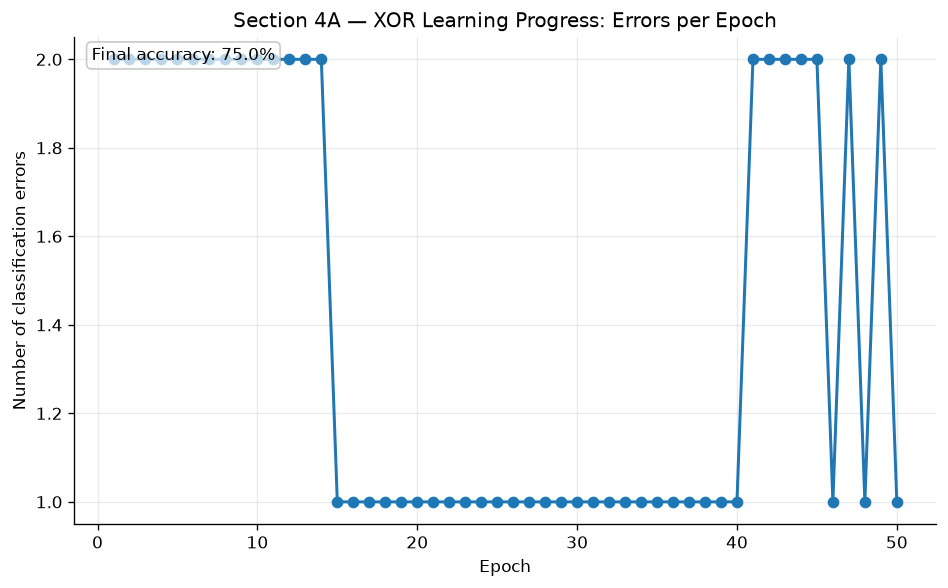


XOR learning summary
Epoch | Errors | Accuracy
----- | ------ | --------
    1 |      2 |   50.00%
    2 |      2 |   50.00%
    3 |      2 |   50.00%
    4 |      2 |   50.00%
    5 |      2 |   50.00%
    6 |      2 |   50.00%
    7 |      2 |   50.00%
    8 |      2 |   50.00%
    9 |      2 |   50.00%
   10 |      2 |   50.00%
   11 |      2 |   50.00%
   12 |      2 |   50.00%
   13 |      2 |   50.00%
   14 |      2 |   50.00%
   15 |      1 |   75.00%
   16 |      1 |   75.00%
   17 |      1 |   75.00%
   18 |      1 |   75.00%
   19 |      1 |   75.00%
   20 |      1 |   75.00%
   21 |      1 |   75.00%
   22 |      1 |   75.00%
   23 |      1 |   75.00%
   24 |      1 |   75.00%
   25 |      1 |   75.00%
   26 |      1 |   75.00%
   27 |      1 |   75.00%
   28 |      1 |   75.00%
   29 |      1 |   75.00%
   30 |      1 |   75.00%
   31 |      1 |   75.00%
   32 |      1 |   75.00%
   33 |      1 |   75.00%
   34 |      1 |   75.00%
   35 |      1 |   75.00%
   36 |      1 |

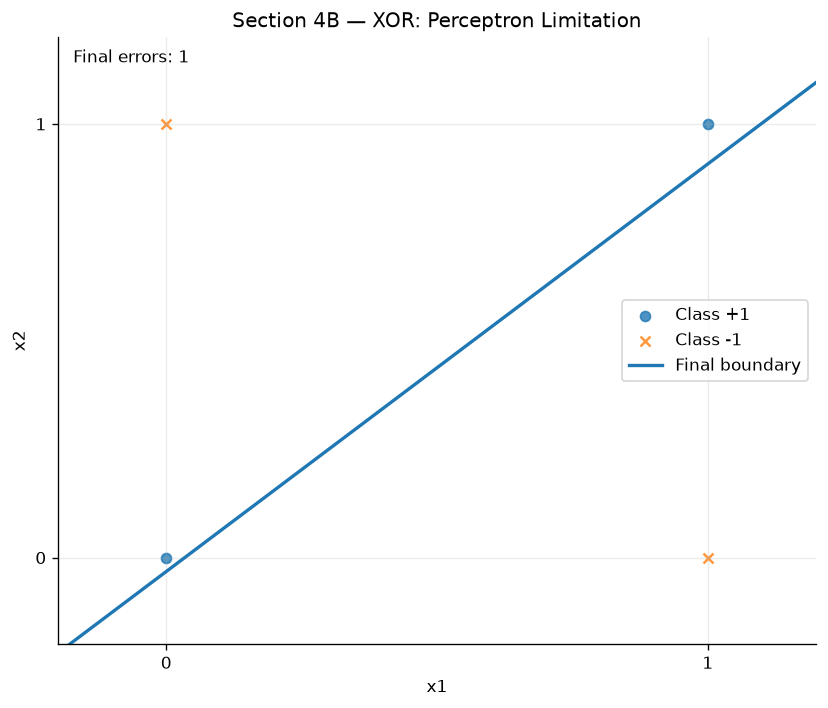

In [46]:

def create_xor_dataset():
    X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
    y_xor = np.array([1, -1, -1, 1], dtype=int)
    return X_xor, y_xor

X_xor, y_xor = create_xor_dataset()
xor_initial_weights = initialize_parameters(seed=RANDOM_SEED)
xor_weight_history = []
xor_final_weights, xor_errors = train_perceptron(X_xor, y_xor, learning_rate=LEARNING_RATE, epochs=EPOCHS, initial_weights=xor_initial_weights, weight_history=xor_weight_history)
print(f'Final XOR weights: {xor_final_weights}')
print(f'XOR errors by epoch: {xor_errors}')
print(f'Final XOR errors: {xor_errors[-1]}')

xor_epochs = np.arange(1, len(xor_errors) + 1)
xor_accuracy = 100 * (1 - np.array(xor_errors) / len(X_xor))
fig_xor_curve, ax_xor_curve = plt.subplots(figsize=(8, 5))
ax_xor_curve.plot(xor_epochs, xor_errors, marker='o', linewidth=1.8)
ax_xor_curve.set_xlabel('Epoch')
ax_xor_curve.set_ylabel('Number of classification errors')
ax_xor_curve.set_title('Section 4A — XOR Learning Progress: Errors per Epoch')
ax_xor_curve.grid(True, alpha=0.25)
ax_xor_curve.text(
    0.02,
    0.98,
    f'Final accuracy: {xor_accuracy[-1]:.1f}%',
    transform=ax_xor_curve.transAxes,
    verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='0.7', boxstyle='round,pad=0.3')
)
fig_xor_curve.tight_layout()
fig_xor_curve.savefig(PLOTS_DIR / '04a_xor_errors_vs_epoch.png', dpi=150)
plt.show()
print()
print('XOR learning summary')
print('Epoch | Errors | Accuracy')
print('----- | ------ | --------')
for epoch, err, acc in zip(xor_epochs, xor_errors, xor_accuracy):
    print(f'{epoch:>5} | {err:>6} | {acc:>7.2f}%')
print()
print(f'Final accuracy: {xor_accuracy[-1]:.2f}%')

fig, ax = plt.subplots(figsize=(7, 6))
plot_data(ax, X_xor, y_xor, 'Section 4B — XOR: Perceptron Limitation')
xs = np.linspace(-0.2, 1.2, 200)
ys = decision_boundary_x(xor_final_weights, xs)
if ys is not None:
    ax.plot(xs, ys, linewidth=2, label='Final boundary')
else:
    ax.axvline(-xor_final_weights[0] / xor_final_weights[1], linewidth=2, label='Final boundary')
ax.set_xlim(-0.2, 1.2)
ax.set_ylim(-0.2, 1.2)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.legend()
ax.text(0.02, 0.98, f'Final errors: {xor_errors[-1]}', transform=ax.transAxes, verticalalignment='top')
fig.tight_layout()
fig.savefig(PLOTS_DIR / '04b_xor_limitation.png', dpi=150)
plt.show()

# Animated version: the line keeps moving, but no line can separate XOR perfectly.
# It freezes at the first step with the best accuracy it ever reached (at most 75%).
animate_boundary(X_xor, y_xor, xor_weight_history, 'Section 4C — Animated XOR Learning',
                 xlim=(-0.5, 1.5), ylim=(-0.5, 1.5),
                 interval=120, save_path=PLOTS_DIR / '04c_xor_learning_animation.gif')
